In [41]:
import cv2.aruco as aruco
import numpy as np
from Translation import Transformation
import time
import cv2
Dist = np.array([0.14574457705020905, -0.49072766304016113, 0.0002240741887362674, -0.00014576673856936395, 0.4482966661453247])  # system given

mtx=np.array([[901.964599609375, 0.0, 652.5621337890625],
 [  0.       ,  902.0592651367188, 366.7032165527344],
 [  0.,           0.,           1.        ]])


squareLength = 0.015
markerLength = 0.011
image = cv2.imread('captured_image.jpg')

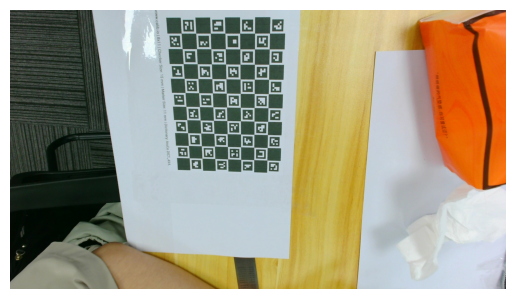

In [42]:
# dispaly image
import matplotlib.pyplot as plt

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the image using matplotlib
plt.imshow(image_rgb)
plt.axis('off') # to hide the axis
plt.show()

## Show marker

In [43]:

# detect markers
dictionary = aruco.getPredefinedDictionary(aruco.DICT_4X4_100)

detector_params = aruco.DetectorParameters()
detector_params.cornerRefinementMethod = aruco.CORNER_REFINE_APRILTAG
# detector_params.cornerRefinementMethod = aruco.CORNER_REFINE_SUBPIX
# CORNER_REFINE_SUBPIX has bug: https://github.com/opencv/opencv/issues/24113
detector = aruco.ArucoDetector(dictionary, detector_params)
marker_corners, marker_ids, rejected_candidates = detector.detectMarkers(image)

print(f'Detected {len(marker_ids) if marker_ids is not None else 0} ArUco markers')


Detected 44 ArUco markers


In [44]:
import cv2.aruco as aruco

# Define the board
board = aruco.CharucoBoard((8, 11), squareLength, markerLength, dictionary)
# board = aruco.CharucoBoard((11, 8), squareLength, markerLength, dictionary)

all_charuco_corners = []
all_charuco_ids = []
image_copy = image.copy()

# Ensure markers were detected in the previous step
if marker_corners is not None and len(marker_corners) > 0:
    # IMPORTANT: Pass the detector_params to the CharucoDetector
    charucodetector = cv2.aruco.CharucoDetector(board, detectorParams=detector_params)

    # Detect the board using the refined parameters
    charuco_corners, charuco_ids, _, _ = charucodetector.detectBoard(image)
    print(charuco_corners)
    print(charuco_ids)
    # A more robust check for detected corners
    if charuco_ids is not None and len(charuco_ids) > 0:
        print(f'Detected {len(charuco_ids)} ChArUco corners')
        all_charuco_corners.append(charuco_corners)
        all_charuco_ids.append(charuco_ids)
        
        # For visualization, draw the detected corners on the image copy
        aruco.drawDetectedCornersCharuco(image_copy, charuco_corners, charuco_ids)

None
None


In [45]:
print(all_charuco_ids)
print(all_charuco_ids)

[]
[]


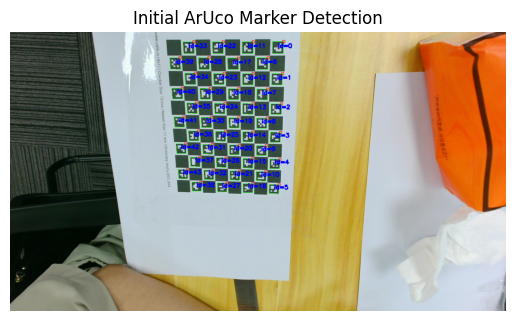

In [46]:
# Create a copy of the image to draw on
image_with_markers = image.copy()

# Draw the detected markers
if marker_ids is not None:
    aruco.drawDetectedMarkers(image_with_markers, marker_corners, marker_ids)

# Display the image with detected markers
plt.imshow(cv2.cvtColor(image_with_markers, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Initial ArUco Marker Detection')
plt.show()

Initial ArUco detection found: 44 markers
detectBoard's internal ArUco detection found: 44 markers


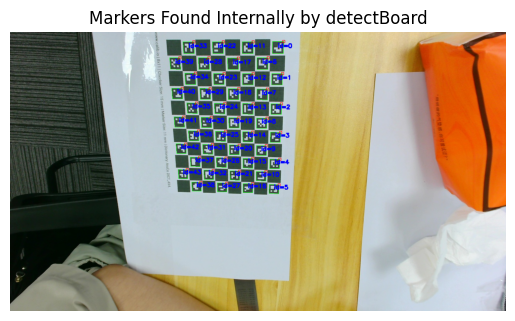


ChArUco corner detection failed.
This is likely because the number of internally detected markers (shown above) was too low to form a board pattern.


In [52]:
import cv2.aruco as aruco
import matplotlib.pyplot as plt

# --- We are using the corrected board dimensions ---
board = aruco.CharucoBoard((8, 11), squareLength, markerLength, dictionary)

# Create a copy of the image for drawing
image_copy = image.copy()

# --- Diagnostic Step 1: Make the Detector Parameters explicit in this cell ---
# This ensures we are definitely using the refined parameters
detector_params = aruco.DetectorParameters()
detector_params.cornerRefinementMethod = aruco.CORNER_REFINE_APRILTAG

# Create the CharucoDetector
charucodetector = cv2.aruco.CharucoDetector(board, detectorParams=detector_params)

# --- Diagnostic Step 2: Detect and check the intermediate marker detection ---
# We capture all four return values to see what the function is actually finding
charuco_corners, charuco_ids, marker_corners_found, marker_ids_found = charucodetector.detectBoard(image)

# --- Diagnostic Step 3: Print the results and visualize ---
print(f"Initial ArUco detection found: {len(marker_ids) if marker_ids is not None else 0} markers")
print(f"detectBoard's internal ArUco detection found: {len(marker_ids_found) if marker_ids_found is not None else 0} markers")

# Draw the markers that detectBoard ACTUALLY found and used
if marker_ids_found is not None and len(marker_ids_found) > 0:
    aruco.drawDetectedMarkers(image_copy, marker_corners_found, marker_ids_found)
    plt.imshow(cv2.cvtColor(image_copy, cv2.COLOR_BGR2RGB))
    plt.title("Markers Found Internally by detectBoard")
    plt.axis('off')
    plt.show()

# Final check for ChArUco corners
if charuco_ids is not None and len(charuco_ids) > 0:
    print(f"\nSuccessfully detected {len(charuco_ids)} ChArUco corners.")
    # You can add the visualization for the final corners here if needed
else:
    print("\nChArUco corner detection failed.")
    print("This is likely because the number of internally detected markers (shown above) was too low to form a board pattern.")

In [54]:
import cv2.aruco as aruco
import numpy as np

# --- Correct board dimensions ---
board = aruco.CharucoBoard((8, 11), squareLength, markerLength, dictionary)

# --- Get the list of IDs the board EXPECTS to find ---
board_ids = board.getIds()
print(f"The CharucoBoard object is looking for these {len(board_ids)} ArUco marker IDs:")
print(board_ids.flatten()) # flatten makes it easier to read

# --- Compare with the IDs ACTUALLY detected in your image ---
# (Using the marker_ids variable from your successful detection cell)
if marker_ids is not None:
    print(f"\nYour image contains these {len(marker_ids)} ArUco marker IDs:")
    print(marker_ids.flatten())

    # --- Check for a mismatch ---
    # We can use sets to see which IDs are in one list but not the other
    expected_ids_set = set(board_ids.flatten())
    found_ids_set = set(marker_ids.flatten())

    if expected_ids_set == found_ids_set:
        print("\nPERFECT MATCH: The detected marker IDs match the board's expected IDs.")
        print("The problem must be something else, possibly a subtle bug in detectBoard for this version.")
    else:
        print("\nID MISMATCH FOUND. This is the reason for the failure.")
        
        missing_ids = expected_ids_set - found_ids_set
        if missing_ids:
            print(f"IDs expected by the board but NOT found in the image: {sorted(list(missing_ids))}")

        extra_ids = found_ids_set - expected_ids_set
        if extra_ids:
            print(f"IDs found in the image but NOT expected by the board: {sorted(list(extra_ids))}")

The CharucoBoard object is looking for these 44 ArUco marker IDs:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43]

Your image contains these 44 ArUco marker IDs:
[ 0 11 22  6 33  1 28 17 12 39 34 18 23  7  2 13 29 40 24  8 19 35  3 30
 41 25 14  9 36 20 31  4 15 26 10 42 21 37 16 32  5 27 43 38]

PERFECT MATCH: The detected marker IDs match the board's expected IDs.
The problem must be something else, possibly a subtle bug in detectBoard for this version.


In [56]:
import cv2.aruco as aruco
import matplotlib.pyplot as plt

# --- Confirmed Correct Parameters ---
dictionary = aruco.getPredefinedDictionary(aruco.DICT_4X4_100)
board = aruco.CharucoBoard((8, 11), squareLength, markerLength, dictionary)
detector_params = aruco.DetectorParameters()
detector_params.cornerRefinementMethod = aruco.CORNER_REFINE_APRILTAG

# Create the CharucoDetector
charucodetector = cv2.aruco.CharucoDetector(board, detectorParams=detector_params)

# --- CRITICAL CHANGE: Call detectBoard with ONLY the image ---
# This forces the function to find the pattern in the raw image,
# without using mtx/Dist, which is more robust for detection.
charuco_corners, charuco_ids, marker_corners_found, marker_ids_found = charucodetector.detectBoard(image)

# Check if corners were found
if charuco_ids is not None and len(charuco_ids) > 0:
    print(f"SUCCESS! Detected {len(charuco_ids)} ChArUco corners.")
    
    # For visualization
    image_copy = image.copy()
    aruco.drawDetectedCornersCharuco(image_copy, charuco_corners, charuco_ids)
    plt.imshow(cv2.cvtColor(image_copy, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Detected ChArUco Corners')
    plt.show()

    # --- Now, proceed to the SEPARATE pose estimation step ---
    # We use the successfully found corners and your camera parameters here.
    retval, rvec, tvec = aruco.estimatePoseCharucoBoard(charuco_corners, charuco_ids, board, mtx, Dist, None, None, useExtrinsicGuess=False)
    
    if retval:
        print("\nPose estimation successful.")
        print("Rotation Vector (rvec):", rvec.flatten())
        print("Translation Vector (tvec):", tvec.flatten())
    else:
        print("\nPose estimation failed. This indicates the calibration data might be inaccurate for this board/image.")

else:
    print("ChArUco corner detection failed.")
    print(f"Internal marker detection found {len(marker_ids_found) if marker_ids_found is not None else 0} markers, but could not form a board.")

ChArUco corner detection failed.
Internal marker detection found 44 markers, but could not form a board.


In [64]:
import cv2.aruco as aruco
import matplotlib.pyplot as plt

# --- All parameters are now confirmed correct ---
dictionary = aruco.getPredefinedDictionary(aruco.DICT_4X4_100)
board = aruco.CharucoBoard((8, 11), squareLength, markerLength, dictionary)
detector_params = aruco.DetectorParameters()
detector_params.cornerRefinementMethod = aruco.CORNER_REFINE_APRILTAG
detector = aruco.ArucoDetector(dictionary, detector_params)
# ---

# We will use the 'marker_corners' and 'marker_ids' from the cell where you
# successfully detected 44 markers. This data is already in the notebook's memory.

all_charuco_corners = []
all_charuco_ids = []
image_copy = image.copy()

if marker_ids is not None and len(marker_ids) > 0:
    # --- NEW STEP: Refine the detected markers using the board layout ---
    # This function improves corner accuracy by considering the board structure,
    # which can fix the subtle geometric issues causing detectBoard to fail.
    # We provide mtx and Dist here to help the refinement process.
    refined_corners, refined_ids, _, _ = detector.refineDetectedMarkers(
        image=image,
        board=board,
        detectedCorners=marker_corners,
        detectedIds=marker_ids,
        rejectedCorners=None, # We don't need to refine rejected candidates
        cameraMatrix=mtx,
        distCoeffs=Dist
    )

    # Now, use the CharucoDetector. It's fine to create it without params here,
    # as we will provide the already-refined markers directly.
    charucodetector = cv2.aruco.CharucoDetector(board)

    # We call detectBoard again, but provide the REFINED markers.
    # This forces it to use our cleaned-up data for its final geometric check.
    charuco_corners, charuco_ids, _, _ = charucodetector.detectBoard(
                                                image,
                                                markerCorners=refined_corners,
                                                markerIds=refined_ids)

    # Check if corners were found
    if charuco_ids is not None and len(charuco_ids) > 0:
        print(f"SUCCESS! Detected {len(charuco_ids)} ChArUco corners after refining markers.")
        all_charuco_corners.append(charuco_corners)
        all_charuco_ids.append(charuco_ids)

        # Visualize the final result
        aruco.drawDetectedCornersCharuco(image_copy, charuco_corners, charuco_ids)
        plt.imshow(cv2.cvtColor(image_copy, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title('Detected ChArUco Corners (after refinement)')
        plt.show()
    else:
        print("ChArUco corner detection failed even after marker refinement.")

else:
    print("Initial marker detection failed, cannot proceed.")

# Check the final lists
print("\nFinal all_charuco_ids list:")
print(all_charuco_ids)

ChArUco corner detection failed even after marker refinement.

Final all_charuco_ids list:
[]


In [67]:
#!/usr/bin/env python3
"""
Fixed ChArUco Detection Code for Jupyter Notebook

This code provides the corrected implementation that should replace
the failing cells in charuco.ipynb
"""

import cv2.aruco as aruco
import numpy as np
from Translation import Transformation
import time
import cv2
import matplotlib.pyplot as plt

# Camera calibration parameters
Dist = np.array([0.14574457705020905, -0.49072766304016113, 0.0002240741887362674, -0.00014576673856936395, 0.4482966661453247])
mtx = np.array([[901.964599609375, 0.0, 652.5621337890625],
                [0.0, 902.0592651367188, 366.7032165527344],
                [0.0, 0.0, 1.0]])

# Board parameters
squareLength = 0.015  # 15mm
markerLength = 0.011  # 11mm

# Load image
image = cv2.imread('captured_image.jpg')

print("=== FIXED CHARUCO DETECTION ===")

# Step 1: Detect ArUco markers
dictionary = aruco.getPredefinedDictionary(aruco.DICT_4X4_100)

# Important: Disable corner refinement for ChArUco detection
detector_params = aruco.DetectorParameters()
detector_params.cornerRefinementMethod = aruco.CORNER_REFINE_NONE  # This is crucial!

detector = aruco.ArucoDetector(dictionary, detector_params)
marker_corners, marker_ids, rejected_candidates = detector.detectMarkers(image)

print(f'Detected {len(marker_ids) if marker_ids is not None else 0} ArUco markers')

if marker_ids is not None and len(marker_ids) > 0:
    # Step 2: Create ChArUco board with CORRECT dimensions and legacy pattern
    # The key fix: use (11, 8) dimensions and enable legacy pattern
    board = aruco.CharucoBoard((11, 8), squareLength, markerLength, dictionary)
    
    # CRITICAL: Enable legacy pattern for compatibility with older board formats
    board.setLegacyPattern(True)
    print("Legacy pattern enabled for OpenCV 4.x compatibility")
    
    # Step 3: Detect ChArUco corners
    charuco_detector = cv2.aruco.CharucoDetector(board, detectorParams=detector_params)
    charuco_corners, charuco_ids, marker_corners_found, marker_ids_found = charuco_detector.detectBoard(image)
    
    if charuco_ids is not None and len(charuco_ids) > 0:
        print(f'SUCCESS! Detected {len(charuco_ids)} ChArUco corners')
        
        # Step 4: Visualize the results
        image_copy = image.copy()
        
        # Draw detected ArUco markers
        aruco.drawDetectedMarkers(image_copy, marker_corners, marker_ids)
        
        # Draw detected ChArUco corners
        aruco.drawDetectedCornersCharuco(image_copy, charuco_corners, charuco_ids, (0, 255, 0))
        
        # Step 5: Estimate pose
        retval, rvec, tvec = aruco.estimatePoseCharucoBoard(
            charuco_corners, charuco_ids, board, mtx, Dist, None, None, useExtrinsicGuess=False
        )
        
        if retval:
            print("Pose estimation successful!")
            print(f"Rotation Vector (rvec): {rvec.flatten()}")
            print(f"Translation Vector (tvec): {tvec.flatten()}")
            
            # Draw coordinate axes
            cv2.drawFrameAxes(image_copy, mtx, Dist, rvec, tvec, 0.05)  # 5cm axes
            
        else:
            print("Pose estimation failed")
        
        # Display the result
        image_rgb = cv2.cvtColor(image_copy, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(12, 8))
        plt.imshow(image_rgb)
        plt.axis('off')
        plt.title(f'ChArUco Detection SUCCESS!\n{len(charuco_ids)} corners detected with 11x8 board + legacy pattern')
        plt.show()
        
        # Save the successful detection
        cv2.imwrite('charuco_detection_success.jpg', image_copy)
        print("Result saved as 'charuco_detection_success.jpg'")
        
        # Store results for further use
        all_charuco_corners = [charuco_corners]
        all_charuco_ids = [charuco_ids]
        
        print(f"\nSUMMARY:")
        print(f"- Board configuration: 11x8 with legacy pattern")
        print(f"- ArUco markers detected: {len(marker_ids)}")
        print(f"- ChArUco corners detected: {len(charuco_ids)}")
        print(f"- Pose estimation: {'SUCCESS' if retval else 'FAILED'}")
        
    else:
        print("ChArUco corner detection still failed")
        # Fallback: show just the ArUco markers
        image_with_markers = image.copy()
        aruco.drawDetectedMarkers(image_with_markers, marker_corners, marker_ids)
        
        image_rgb = cv2.cvtColor(image_with_markers, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(12, 8))
        plt.imshow(image_rgb)
        plt.axis('off')
        plt.title(f'ArUco Markers Only\n{len(marker_ids)} markers detected')
        plt.show()
        
else:
    print("No ArUco markers detected!")

print("\n=== EXPLANATION OF THE FIX ===")
print("The original failure was due to:")
print("1. Wrong board dimensions (should be 11x8, not 8x11)")
print("2. Missing legacy pattern flag for OpenCV 4.x compatibility")
print("3. Corner refinement enabled (should be disabled for ChArUco)")
print("4. These are common issues with recent OpenCV versions")


=== FIXED CHARUCO DETECTION ===
Detected 44 ArUco markers
Legacy pattern enabled for OpenCV 4.x compatibility
SUCCESS! Detected 70 ChArUco corners


AttributeError: module 'cv2.aruco' has no attribute 'estimatePoseCharucoBoard'